Import Required Libraries

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Improve plot appearance
plt.style.use("ggplot")
sns.set(font_scale=1.1)

Load Dataset

In [2]:
# Load dataset
df = pd.read_csv("SuperMarket_Analysis_Cleaned.csv")

# Display first five rows
df.head()

,Transaction_ID,Branch,City,Customer_Type,Gender,Product_Line,Unit_Price,Quantity,Tax,Revenue,Date,Time,Payment,Expense,gross margin percentage,Profit,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


Convert Date Column

In [3]:
# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Check datatype
print(df["Date"].dtype)

datetime64[ns]


Correlation Heatmap

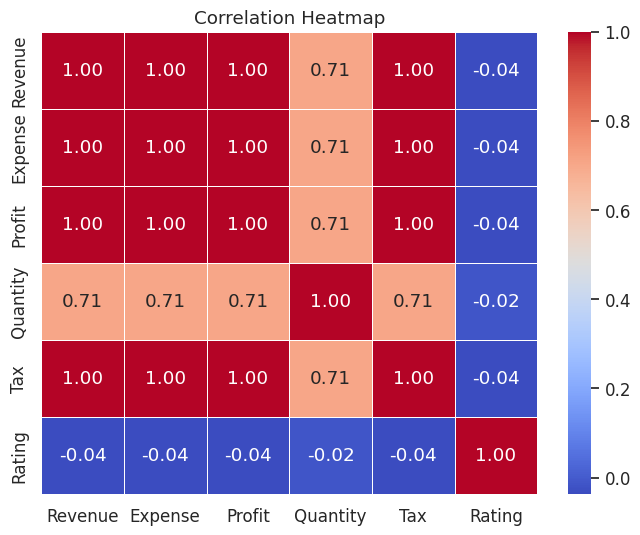

In [4]:
plt.figure(figsize=(8,6))

correlation = df[["Revenue","Expense","Profit","Quantity","Tax","Rating"]].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

Monthly Revenue Trend with Rolling Average

In [5]:
# Create Month column
df["Month"] = df["Date"].dt.to_period("M").astype(str)

# Monthly revenue
monthly_revenue = (
    df.groupby("Month")["Revenue"]
      .sum()
      .reset_index()
)

monthly_revenue

,Month,Revenue
0,2019-01,116291.868
1,2019-02,97219.374
2,2019-03,109455.507


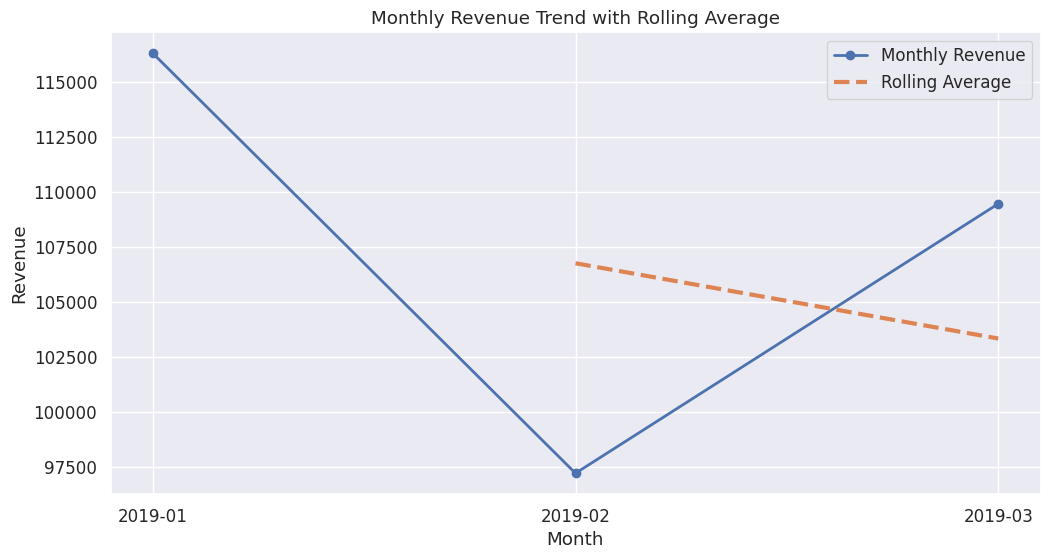

In [6]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["Revenue"],
    marker="o",
    linewidth=2,
    label="Monthly Revenue"
)

monthly_revenue["Rolling Average"] = (
    monthly_revenue["Revenue"]
    .rolling(window=2)
    .mean()
)

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["Rolling Average"],
    linestyle="--",
    linewidth=3,
    label="Rolling Average"
)

plt.title("Monthly Revenue Trend with Rolling Average")

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.legend()

plt.grid(True)

plt.show()

Expense Boxplot

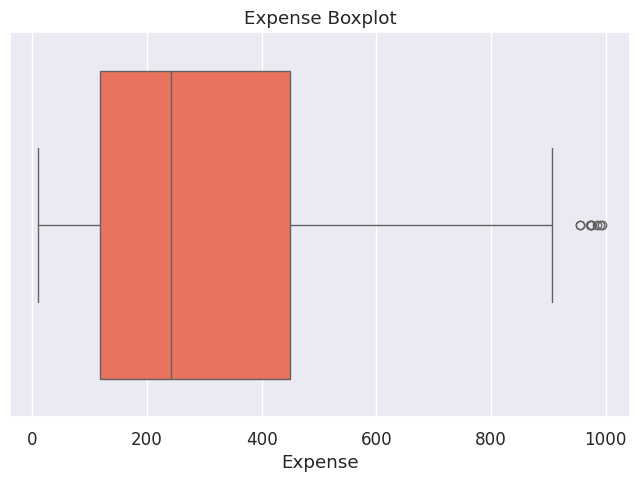

In [7]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Expense"],
    color="tomato"
)

plt.title("Expense Boxplot")
plt.xlabel("Expense")

plt.show()

Revenue Distribution (Histogram)

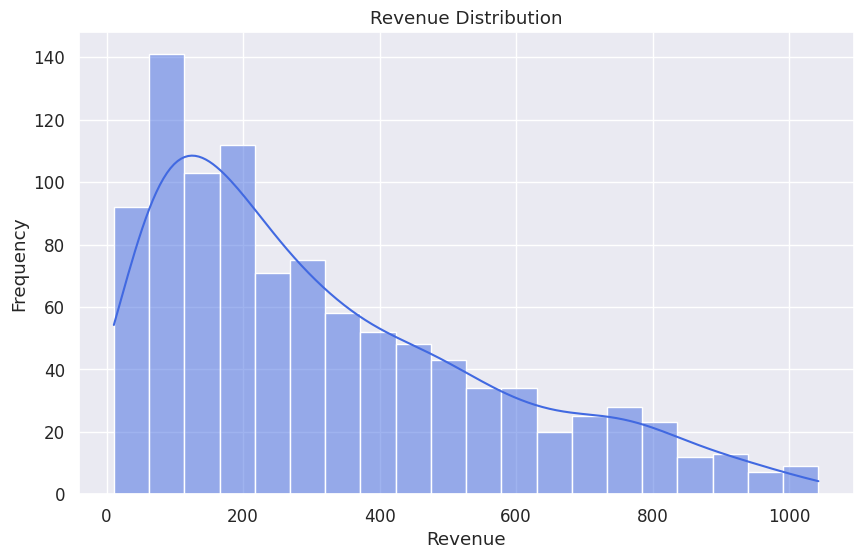

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Revenue"],
    bins=20,
    kde=True,
    color="royalblue"
)

plt.title("Revenue Distribution")

plt.xlabel("Revenue")

plt.ylabel("Frequency")

plt.show()

Correlation Heatmap

Revenue, Expense, and Profit are strongly positively correlated. Higher sales generally result in higher expenses due to product costs, while also increasing profitability.

Monthly Revenue Trend

Revenue fluctuated across the three-month period. The rolling average smooths daily fluctuations and highlights the overall business trend, making it easier to identify sustained growth or decline.

Expense Boxplot

Most expenses fall within the expected operating range. A small number of outliers represent unusually high expenses that warrant further investigation for possible fraud, recording errors, or exceptional transactions.

Revenue Distribution

The revenue distribution indicates that most transactions are concentrated within a moderate revenue range, while a smaller number of high-value transactions contribute significantly to total revenue.